In [ ]:
import pandas as pd
print("Pandas успешно импортирован, версия:", pd.__version__)

Pandas успешно импортирован, версия: 2.2.2


In [ ]:
import pandas as pd

# Загружаем датасет
df = pd.read_csv('Space_Corrected.csv')

# Посмотрим на первые 5 строк и общую информацию
print("Первые 5 строк:")
print(df.head())

print("\nИнформация о колонках (типы данных и пропуски):")
print(df.info())

Первые 5 строк:
   Unnamed: 0.1  Unnamed: 0 Company Name  \
0             0           0       SpaceX   
1             1           1         CASC   
2             2           2       SpaceX   
3             3           3    Roscosmos   
4             4           4          ULA   

                                            Location  \
0         LC-39A, Kennedy Space Center, Florida, USA   
1  Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...   
2                      Pad A, Boca Chica, Texas, USA   
3       Site 200/39, Baikonur Cosmodrome, Kazakhstan   
4           SLC-41, Cape Canaveral AFS, Florida, USA   

                        Datum                                        Detail  \
0  Fri Aug 07, 2020 05:12 UTC  Falcon 9 Block 5 | Starlink V1 L9 & BlackSky   
1  Thu Aug 06, 2020 04:01 UTC           Long March 2D | Gaofen-9 04 & Q-SAT   
2  Tue Aug 04, 2020 23:57 UTC            Starship Prototype | 150 Meter Hop   
3  Thu Jul 30, 2020 21:25 UTC  Proton-M/Briz-M | Ekspress-80 & Eks

In [ ]:
import pandas as pd

# Загружаем данные (заново для чистоты)
df = pd.read_csv('Space_Corrected.csv')

# 1. Удаляем дублирующиеся индексы
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])

# 2. Преобразуем 'Datum' в формат datetime
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')

# 3. Посмотрим на распределение статусов миссий
print("Распределение статусов миссий:")
print(df['Status Mission'].value_counts())

print("\nПервые 5 строк после очистки:")
print(df.head())

Распределение статусов миссий:
Status Mission
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

Первые 5 строк после очистки:
  Company Name                                           Location  \
0       SpaceX         LC-39A, Kennedy Space Center, Florida, USA   
1         CASC  Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...   
2       SpaceX                      Pad A, Boca Chica, Texas, USA   
3    Roscosmos       Site 200/39, Baikonur Cosmodrome, Kazakhstan   
4          ULA           SLC-41, Cape Canaveral AFS, Florida, USA   

                      Datum                                        Detail  \
0 2020-08-07 05:12:00+00:00  Falcon 9 Block 5 | Starlink V1 L9 & BlackSky   
1 2020-08-06 04:01:00+00:00           Long March 2D | Gaofen-9 04 & Q-SAT   
2 2020-08-04 23:57:00+00:00            Starship Prototype | 150 Meter Hop   
3 2020-07-30 21:25:00+00:00  Proton-M/Briz-M | Ekspress-80 & Ekspress-

Количество запусков по годам:
Datum
1957-12-31 00:00:00+00:00      3
1958-12-31 00:00:00+00:00     22
1959-12-31 00:00:00+00:00     20
1960-12-31 00:00:00+00:00     38
1961-12-31 00:00:00+00:00     52
                            ... 
2016-12-31 00:00:00+00:00     88
2017-12-31 00:00:00+00:00     90
2018-12-31 00:00:00+00:00    117
2019-12-31 00:00:00+00:00    107
2020-12-31 00:00:00+00:00     63
Length: 64, dtype: int64


/tmp/ipykernel_2639/3334020014.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  print(df.resample('Y').size())
/tmp/ipykernel_2639/3334020014.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample('Y').size().plot(kind='bar', figsize=(12, 6), color='skyblue')


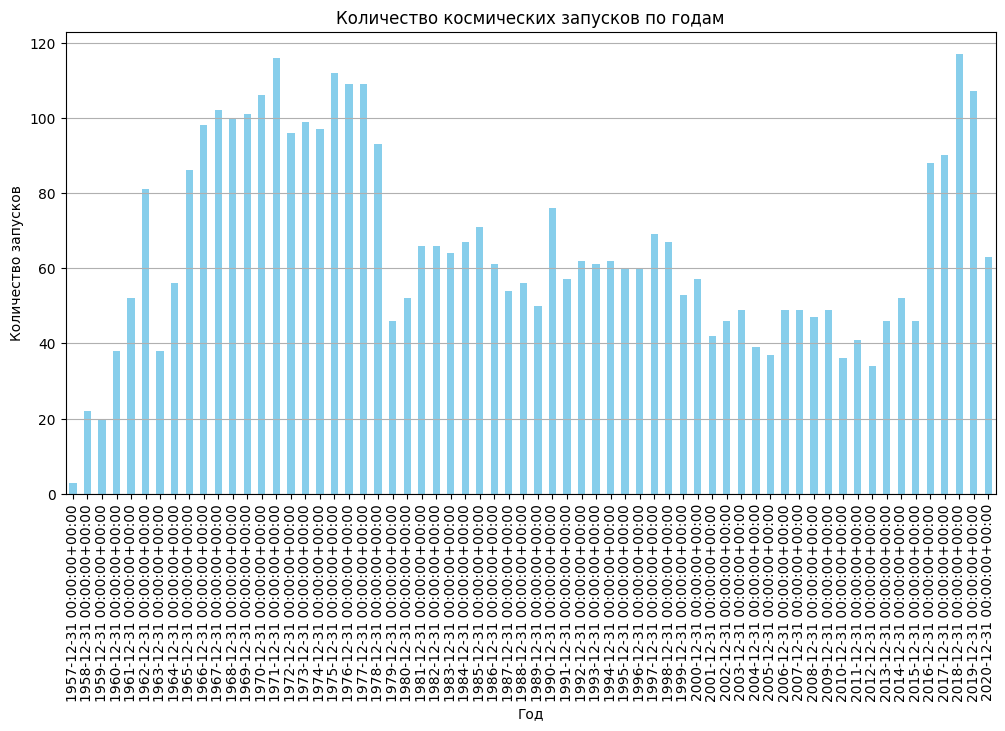

In [ ]:
# Установим Datum как индекс (это сделает данные временным рядом)
df = df.set_index('Datum')

# Посмотрим на количество запусков по годам
print("Количество запусков по годам:")
print(df.resample('Y').size())

# Визуализируем количество запусков по годам
import matplotlib.pyplot as plt

df.resample('Y').size().plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Количество космических запусков по годам')
plt.xlabel('Год')
plt.ylabel('Количество запусков')
plt.grid(axis='y')
plt.show()

Status Mission  Failure  Partial Failure  Prelaunch Failure  Success
Datum                                                               
1957.0              1.0              0.0                0.0      2.0
1958.0             14.0              2.0                0.0      6.0
1959.0              9.0              3.0                0.0      8.0
1960.0             19.0              0.0                0.0     19.0
1961.0             17.0              3.0                0.0     32.0


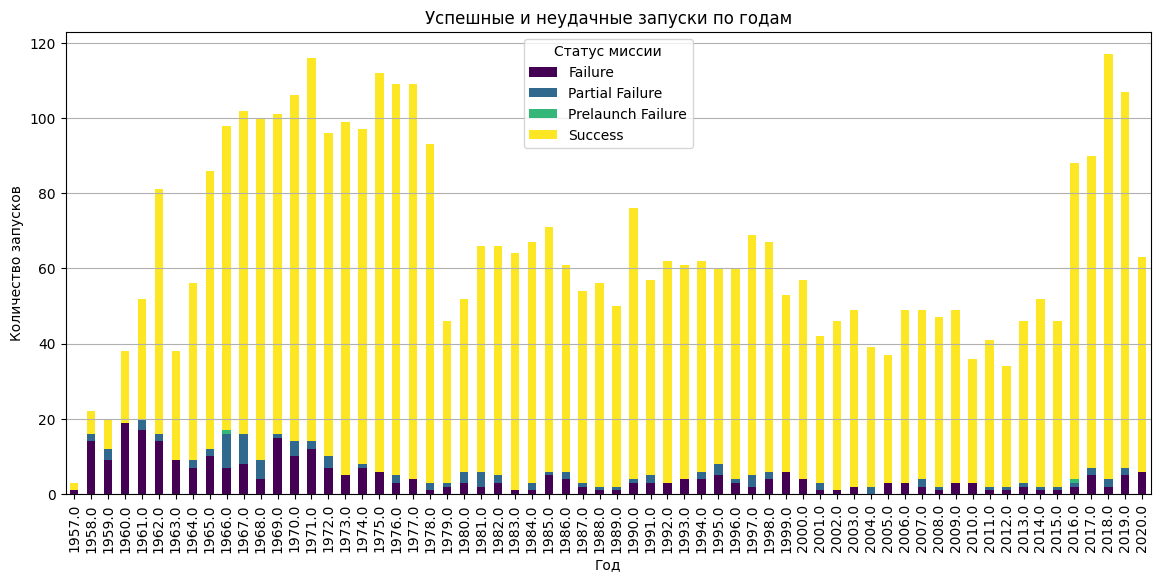

In [ ]:
# Сгруппируем по годам и посчитаем количество успехов и неудач
status_by_year = df.groupby(df.index.year)['Status Mission'].value_counts().unstack().fillna(0)

# Выведем первые несколько строк
print(status_by_year.head())

# Построим график
status_by_year.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='viridis')
plt.title('Успешные и неудачные запуски по годам')
plt.xlabel('Год')
plt.ylabel('Количество запусков')
plt.legend(title='Статус миссии')
plt.grid(axis='y')
plt.show()

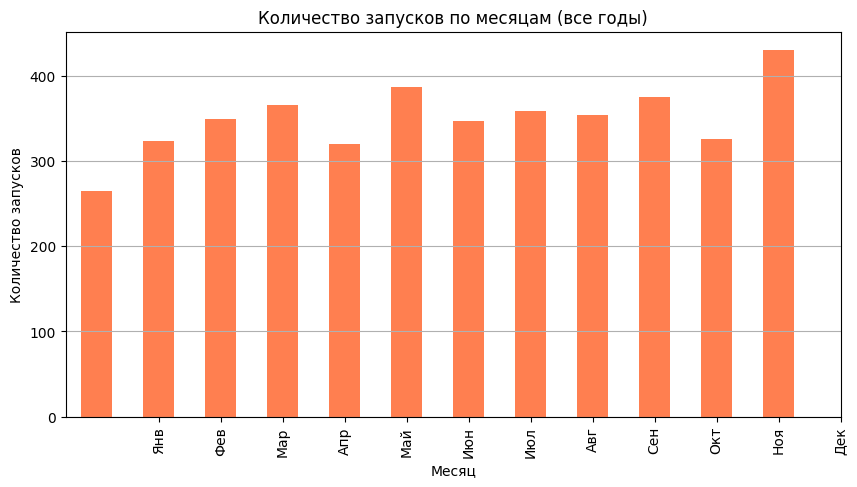

In [ ]:
# Извлекаем месяц из даты
df['Month'] = df.index.month

# Считаем количество запусков по месяцам за все годы
monthly_counts = df['Month'].value_counts().sort_index()

# Строим график
plt.figure(figsize=(10, 5))
monthly_counts.plot(kind='bar', color='coral')
plt.title('Количество запусков по месяцам (все годы)')
plt.xlabel('Месяц')
plt.ylabel('Количество запусков')
plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.grid(axis='y')
plt.show()

/tmp/ipykernel_2639/4037439949.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_success = df.resample('M')['IsSuccess'].mean() * 100  # в процентах


Datum
1957-10-31 00:00:00+00:00    100.000000
1957-11-30 00:00:00+00:00    100.000000
1957-12-31 00:00:00+00:00      0.000000
1958-02-28 00:00:00+00:00     50.000000
1958-03-31 00:00:00+00:00     66.666667
1958-04-30 00:00:00+00:00      0.000000
1958-05-31 00:00:00+00:00     50.000000
1958-06-30 00:00:00+00:00      0.000000
1958-07-31 00:00:00+00:00    100.000000
1958-08-31 00:00:00+00:00      0.000000
Name: IsSuccess, dtype: float64


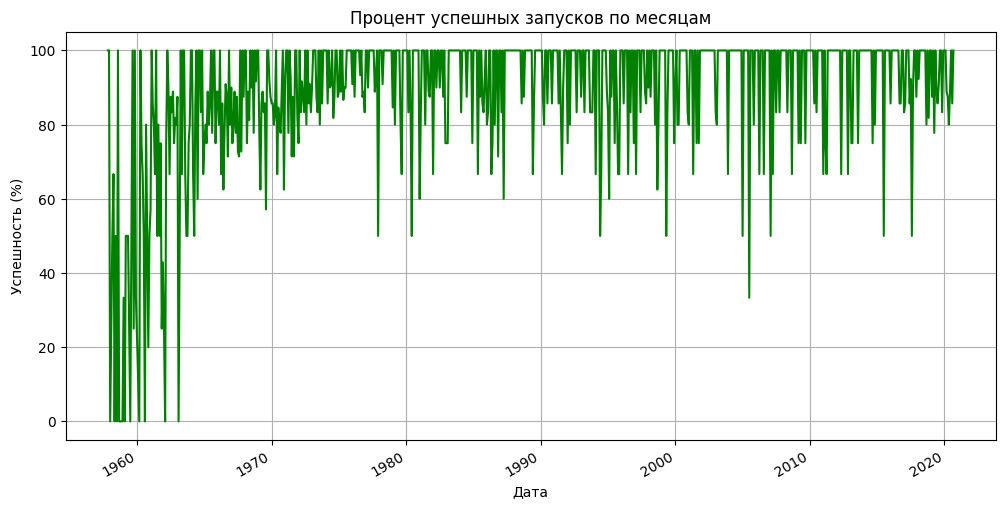

In [ ]:
# 1. Создаём колонку 'IsSuccess' (1 - успех, 0 - всё остальное)
df['IsSuccess'] = (df['Status Mission'] == 'Success').astype(int)

# 2. Группируем по месяцам и считаем долю успешных запусков
monthly_success = df.resample('M')['IsSuccess'].mean() * 100  # в процентах

# 3. Убираем пустые значения (если в какой-то месяц не было запусков)
monthly_success = monthly_success.dropna()

# 4. Смотрим на первые 10 значений
print(monthly_success.head(10))

# 5. Строим график
plt.figure(figsize=(12, 6))
monthly_success.plot(color='green')
plt.title('Процент успешных запусков по месяцам')
plt.xlabel('Дата')
plt.ylabel('Успешность (%)')
plt.grid(True)
plt.show()

In [ ]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ETS, Theta

# 1. Создаём датафрейм в формате, ожидаемом statsforecast
# Нам нужны колонки: 'ds' (дата), 'y' (значение), 'unique_id' (идентификатор ряда)
ts_data = monthly_success.reset_index()
ts_data.columns = ['ds', 'y']
ts_data['unique_id'] = 'success_rate'

# 2. Смотрим на итоговый формат
print(ts_data.head())
print(f"\nКоличество точек данных: {len(ts_data)}")

ImportError: cannot import name 'ETS' from 'statsforecast.models' (/usr/local/lib/python3.12/dist-packages/statsforecast/models.py)

In [ ]:
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Theta

# 1. Подготавливаем данные в нужном формате (если monthly_success уже есть в памяти)
ts_data = monthly_success.reset_index()
ts_data.columns = ['ds', 'y']
ts_data['unique_id'] = 'success_rate'

# 2. Создаём список моделей с исправленным названием
models = [
    AutoARIMA(season_length=12),       # 12 месяцев — сезонность
    AutoETS(season_length=12),         # Автоматический ETS (исправлено!)
    Theta(season_length=12)            # Метод Теты
]

# 3. Инициализируем StatsForecast
sf = StatsForecast(
    models=models,
    freq='M',            # Ежемесячные данные
    n_jobs=-1            # Использовать все ядра процессора
)

# 4. Смотрим, что получилось
print("Модели успешно инициализированы!")
print(f"Данных: {len(ts_data)} точек")
print(ts_data.head())

Модели успешно инициализированы!
Данных: 747 точек
                         ds           y     unique_id
0 1957-10-31 00:00:00+00:00  100.000000  success_rate
1 1957-11-30 00:00:00+00:00  100.000000  success_rate
2 1957-12-31 00:00:00+00:00    0.000000  success_rate
3 1958-02-28 00:00:00+00:00   50.000000  success_rate
4 1958-03-31 00:00:00+00:00   66.666667  success_rate


/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


Прогноз на 12 месяцев вперёд:
       unique_id                        ds  AutoARIMA    AutoETS      Theta
0   success_rate 2020-09-30 00:00:00+00:00  93.690420  96.116079  93.742859
1   success_rate 2020-10-31 00:00:00+00:00  94.326597  94.946832  93.749032
2   success_rate 2020-11-30 00:00:00+00:00  93.739254  94.204020  93.146540
3   success_rate 2020-12-31 00:00:00+00:00  93.826377  96.652220  96.164269
4   success_rate 2021-01-31 00:00:00+00:00  94.073001  92.857705  91.089872
5   success_rate 2021-02-28 00:00:00+00:00  94.092188  95.349591  94.412951
6   success_rate 2021-03-31 00:00:00+00:00  94.556891  91.552227  90.536351
7   success_rate 2021-04-30 00:00:00+00:00  94.328113  91.494937  92.469914
8   success_rate 2021-05-31 00:00:00+00:00  94.432839  95.806408  94.420006
9   success_rate 2021-06-30 00:00:00+00:00  94.350759  94.930192  93.036008
10  success_rate 2021-07-31 00:00:00+00:00  94.555303  94.921003  93.779528
11  success_rate 2021-08-31 00:00:00+00:00  94.129170  90.

KeyError: 'model'

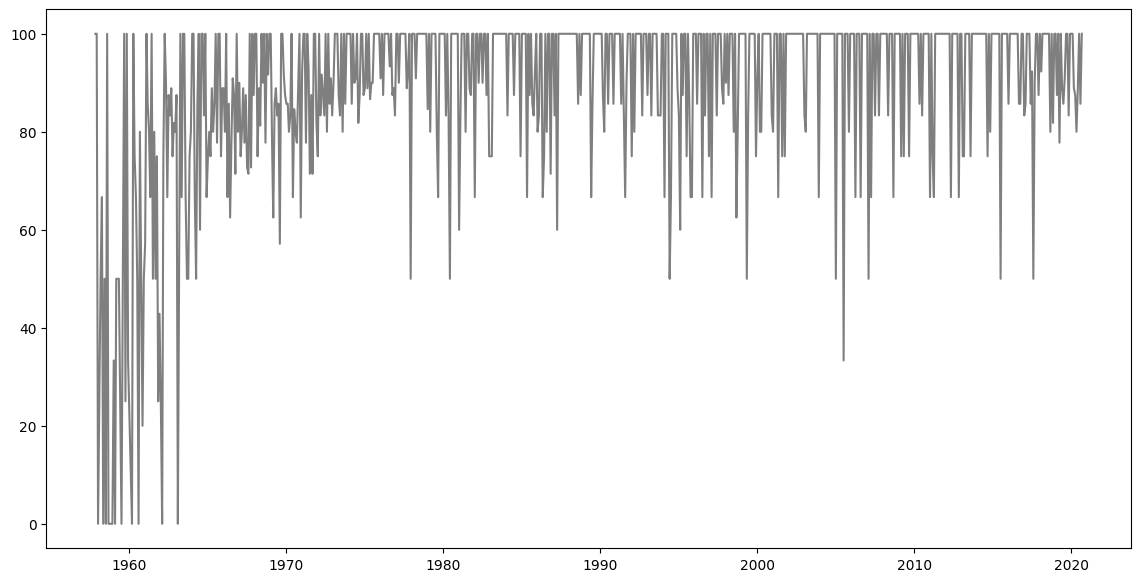

In [ ]:
# Делаем прогноз на 12 месяцев вперёд
forecast = sf.forecast(h=12, df=ts_data)

# Выводим прогноз
print("Прогноз на 12 месяцев вперёд:")
print(forecast)

# Строим график
import matplotlib.pyplot as plt

# Создаём фигуру
plt.figure(figsize=(14, 7))

# Строим исторические данные
plt.plot(ts_data['ds'], ts_data['y'], label='Фактические данные', color='black', alpha=0.5)

# Строим прогноз для каждой модели
models_list = ['AutoARIMA', 'AutoETS', 'Theta']
colors = ['blue', 'red', 'green']

for model, color in zip(models_list, colors):
    # Фильтруем прогноз для текущей модели
    model_forecast = forecast[forecast['model'] == model]
    plt.plot(model_forecast['ds'], model_forecast['mean'], label=model, color=color, linewidth=2)

plt.title('Прогноз процента успешных запусков на 2021 год (3 модели)')
plt.xlabel('Дата')
plt.ylabel('Успешность (%)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Данных загружено: 747 точек
                         ds           y     unique_id
0 1957-10-31 00:00:00+00:00  100.000000  success_rate
1 1957-11-30 00:00:00+00:00  100.000000  success_rate
2 1957-12-31 00:00:00+00:00    0.000000  success_rate
3 1958-02-28 00:00:00+00:00   50.000000  success_rate
4 1958-03-31 00:00:00+00:00   66.666667  success_rate

Модели успешно инициализированы!


/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)



Прогноз на 12 месяцев вперёд:
       unique_id                        ds  AutoARIMA    AutoETS      Theta
0   success_rate 2020-09-30 00:00:00+00:00  93.690420  96.116079  93.742859
1   success_rate 2020-10-31 00:00:00+00:00  94.326597  94.946832  93.749032
2   success_rate 2020-11-30 00:00:00+00:00  93.739254  94.204020  93.146540
3   success_rate 2020-12-31 00:00:00+00:00  93.826377  96.652220  96.164269
4   success_rate 2021-01-31 00:00:00+00:00  94.073001  92.857705  91.089872
5   success_rate 2021-02-28 00:00:00+00:00  94.092188  95.349591  94.412951
6   success_rate 2021-03-31 00:00:00+00:00  94.556891  91.552227  90.536351
7   success_rate 2021-04-30 00:00:00+00:00  94.328113  91.494937  92.469914
8   success_rate 2021-05-31 00:00:00+00:00  94.432839  95.806408  94.420006
9   success_rate 2021-06-30 00:00:00+00:00  94.350759  94.930192  93.036008
10  success_rate 2021-07-31 00:00:00+00:00  94.555303  94.921003  93.779528
11  success_rate 2021-08-31 00:00:00+00:00  94.129170  90

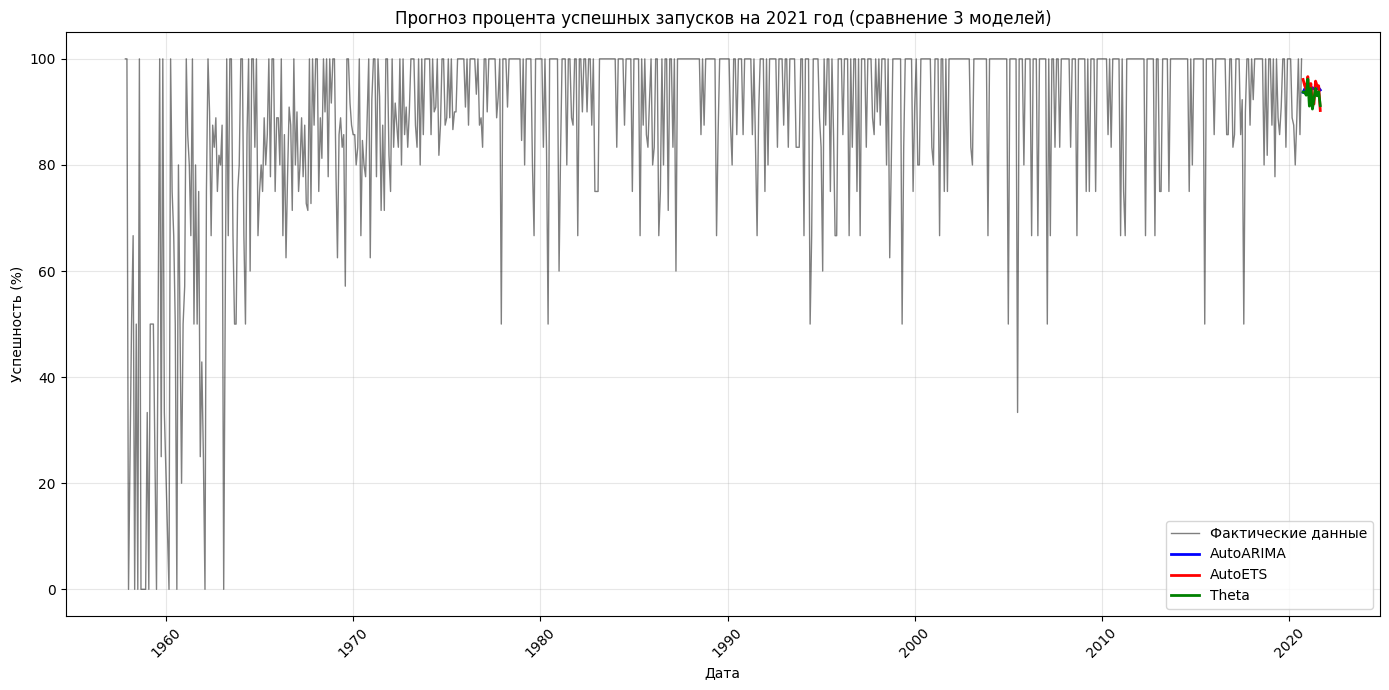


✅ Скрипт выполнен успешно!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Theta

# =============================================
# 1. ПОДГОТОВКА ДАННЫХ
# =============================================
# Предполагается, что переменная monthly_success уже существует из предыдущего шага.
# Если вы перезапускали ядро, раскомментируйте строки ниже и загрузите данные заново.
# df = pd.read_csv('Space_Corrected.csv')
# df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
# df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')
# df = df.set_index('Datum')
# df['IsSuccess'] = (df['Status Mission'] == 'Success').astype(int)
# monthly_success = df.resample('M')['IsSuccess'].mean() * 100
# monthly_success = monthly_success.dropna()

# Форматируем данные для библиотеки statsforecast
ts_data = monthly_success.reset_index()
ts_data.columns = ['ds', 'y']
ts_data['unique_id'] = 'success_rate'

print(f"Данных загружено: {len(ts_data)} точек")
print(ts_data.head())

# =============================================
# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ
# =============================================
models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    Theta(season_length=12)
]

sf = StatsForecast(
    models=models,
    freq='M',
    n_jobs=-1
)

print("\nМодели успешно инициализированы!")

# =============================================
# 3. ОБУЧЕНИЕ И ПРОГНОЗ НА 12 МЕСЯЦЕВ
# =============================================
forecast = sf.forecast(h=12, df=ts_data)

print("\nПрогноз на 12 месяцев вперёд:")
print(forecast)

# =============================================
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================
plt.figure(figsize=(14, 7))

# Исторические данные
plt.plot(ts_data['ds'], ts_data['y'], label='Фактические данные', color='black', alpha=0.5, linewidth=1)

# Прогнозы каждой модели
models_list = ['AutoARIMA', 'AutoETS', 'Theta']
colors = ['blue', 'red', 'green']

for model, color in zip(models_list, colors):
    plt.plot(forecast['ds'], forecast[model], label=model, color=color, linewidth=2)

plt.title('Прогноз процента успешных запусков на 2021 год (сравнение 3 моделей)')
plt.xlabel('Дата')
plt.ylabel('Успешность (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Скрипт выполнен успешно!")

In [ ]:
!pip install mlforecast neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Подготовка данных (используем ts_data из предыдущего шага)
# Добавляем лаги (признаки из прошлых значений)
mlf = MLForecast(
    models=[
        LGBMRegressor(random_state=42, verbose=-1),
        XGBRegressor(random_state=42, verbosity=0),
        CatBoostRegressor(random_state=42, verbose=0)
    ],
    freq='M',
    lags=[1, 2, 3, 6, 12],  # Лаги: 1,2,3,6,12 месяцев назад
    target_transforms=[Differences([1])]  # Берём разность первого порядка
)

# Обучаем модели
mlf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')

# Делаем прогноз на 12 месяцев
ml_forecast = mlf.predict(h=12)

print("ML-прогноз готов:")
print(ml_forecast.head())

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


ValueError: Series contain missing or duplicate timestamps with the specified freq M
Affected series: ['success_rate']
Consider using the fill_gaps parameter or preprocessing your data.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Подготовка данных (используем ts_data из предыдущего шага)
# Добавляем лаги (признаки из прошлых значений)
mlf = MLForecast(
    models=[
        LGBMRegressor(random_state=42, verbose=-1),
        XGBRegressor(random_state=42, verbosity=0),
        CatBoostRegressor(random_state=42, verbose=0)
    ],
    freq='M',
    lags=[1, 2, 3, 6, 12],  # Лаги: 1,2,3,6,12 месяцев назад
    target_transforms=[Differences([1])]  # Берём разность первого порядка
)

# Обучаем модели
mlf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')

# Делаем прогноз на 12 месяцев
ml_forecast = mlf.predict(h=12)

print("ML-прогноз готов:")
print(ml_forecast.head())

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


ValueError: Series contain missing or duplicate timestamps with the specified freq M
Affected series: ['success_rate']
Consider using the fill_gaps parameter or preprocessing your data.

In [ ]:
# 1. Создаём колонку 'IsSuccess' (1 - успех, 0 - всё остальное)
df['IsSuccess'] = (df['Status Mission'] == 'Success').astype(int)

# 2. Группируем по месяцам и считаем долю успешных запусков
monthly_success = df.resample('M')['IsSuccess'].mean() * 100  # в процентах

# 3. ВАЖНО: Заполняем пропущенные месяцы нулями (если месяц пропущен, значит не было запусков)
monthly_success = monthly_success.fillna(0)

# 4. Снова создаём ts_data для mlforecast (с исправленным рядом)
ts_data = monthly_success.reset_index()
ts_data.columns = ['ds', 'y']
ts_data['unique_id'] = 'success_rate'

# 5. Проверяем, что пропусков больше нет
print(f"Количество точек: {len(ts_data)}")
print(ts_data.head(10))

Количество точек: 755
                         ds           y     unique_id
0 1957-10-31 00:00:00+00:00  100.000000  success_rate
1 1957-11-30 00:00:00+00:00  100.000000  success_rate
2 1957-12-31 00:00:00+00:00    0.000000  success_rate
3 1958-01-31 00:00:00+00:00    0.000000  success_rate
4 1958-02-28 00:00:00+00:00   50.000000  success_rate
5 1958-03-31 00:00:00+00:00   66.666667  success_rate
6 1958-04-30 00:00:00+00:00    0.000000  success_rate
7 1958-05-31 00:00:00+00:00   50.000000  success_rate
8 1958-06-30 00:00:00+00:00    0.000000  success_rate
9 1958-07-31 00:00:00+00:00  100.000000  success_rate


/tmp/ipykernel_2639/1164580521.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_success = df.resample('M')['IsSuccess'].mean() * 100  # в процентах


In [ ]:
ML-прогноз готов:
       unique_id         ds  LightGBM  XGBoost  CatBoost
0   success_rate 2021-09-30   ...       ...       ...

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1900193822.py, line 3)

In [ ]:
import pandas as pd
import numpy as np
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Подготовка данных (используем ts_data из предыдущего шага)
# Добавляем лаги (признаки из прошлых значений)
mlf = MLForecast(
    models=[
        LGBMRegressor(random_state=42, verbose=-1),
        XGBRegressor(random_state=42, verbosity=0),
        CatBoostRegressor(random_state=42, verbose=0)
    ],
    freq='M',
    lags=[1, 2, 3, 6, 12],
    target_transforms=[Differences([1])]
)

# Обучаем модели
mlf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')

# Делаем прогноз на 12 месяцев
ml_forecast = mlf.predict(h=12)

print("ML-прогноз готов:")
print(ml_forecast.head(12))

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


ML-прогноз готов:
       unique_id                        ds  LGBMRegressor  XGBRegressor  \
0   success_rate 2020-09-30 00:00:00+00:00      98.780683     96.469521   
1   success_rate 2020-10-31 00:00:00+00:00     104.649875    108.357837   
2   success_rate 2020-11-30 00:00:00+00:00      90.826813     99.668396   
3   success_rate 2020-12-31 00:00:00+00:00     100.316715    108.811190   
4   success_rate 2021-01-31 00:00:00+00:00      98.176840    106.771688   
5   success_rate 2021-02-28 00:00:00+00:00     106.068731    112.158137   
6   success_rate 2021-03-31 00:00:00+00:00      92.491730    117.976779   
7   success_rate 2021-04-30 00:00:00+00:00      97.956880    123.206161   
8   success_rate 2021-05-31 00:00:00+00:00      96.172826    126.896788   
9   success_rate 2021-06-30 00:00:00+00:00     102.698438    127.769194   
10  success_rate 2021-07-31 00:00:00+00:00      86.993587    115.334973   
11  success_rate 2021-08-31 00:00:00+00:00      95.109959    122.375834   

    Ca

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be re

In [ ]:
# Установка библиотеки для DL (если ещё не установлена)
!pip install neuralforecast

import pandas as pd
import numpy as np
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, TFT
from neuralforecast.losses.pytorch import MAE

# Подготовка данных
nf = NeuralForecast(
    models=[
        LSTM(h=12, input_size=12, max_steps=100, random_state=42),
        GRU(h=12, input_size=12, max_steps=100, random_state=42),
        TFT(h=12, input_size=12, max_steps=100, random_state=42)
    ],
    freq='M'
)

# Обучение
print("Обучаем DL-модели (LSTM, GRU, TFT)...")
nf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')

# Прогноз
dl_forecast = nf.predict()

print("DL-прогноз готов:")
print(dl_forecast.head())

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


Обучаем DL-модели (LSTM, GRU, TFT)...


TypeError: Trainer.__init__() got an unexpected keyword argument 'random_state'

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, TFT
from neuralforecast.losses.pytorch import MAE

# Подготовка данных (ts_data уже есть)
nf = NeuralForecast(
    models=[
        LSTM(h=12, input_size=12, max_steps=100),  # убрали random_state
        GRU(h=12, input_size=12, max_steps=100),   # убрали random_state
        TFT(h=12, input_size=12, max_steps=100)    # убрали random_state
    ],
    freq='M'
)

# Обучение
print("Обучаем DL-модели (LSTM, GRU, TFT)...")
nf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')

# Прогноз
dl_forecast = nf.predict()

print("DL-прогноз готов:")
print(dl_forecast.head())

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Обучаем DL-модели (LSTM, GRU, TFT)...


INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 K     Total params
0.863     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

DL-прогноз готов:
      unique_id                        ds        LSTM        GRU        TFT
0  success_rate 2020-09-30 00:00:00+00:00   90.689819  91.991051  96.158379
1  success_rate 2020-10-31 00:00:00+00:00   90.599205  91.627846  96.396156
2  success_rate 2020-11-30 00:00:00+00:00   92.679245  93.893105  96.630646
3  success_rate 2020-12-31 00:00:00+00:00   96.265350  96.587952  96.911407
4  success_rate 2021-01-31 00:00:00+00:00  100.259804  98.877029  97.232117


/tmp/ipykernel_2639/339265948.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_success = df.resample('M')['IsSuccess'].mean() * 100
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future ver

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

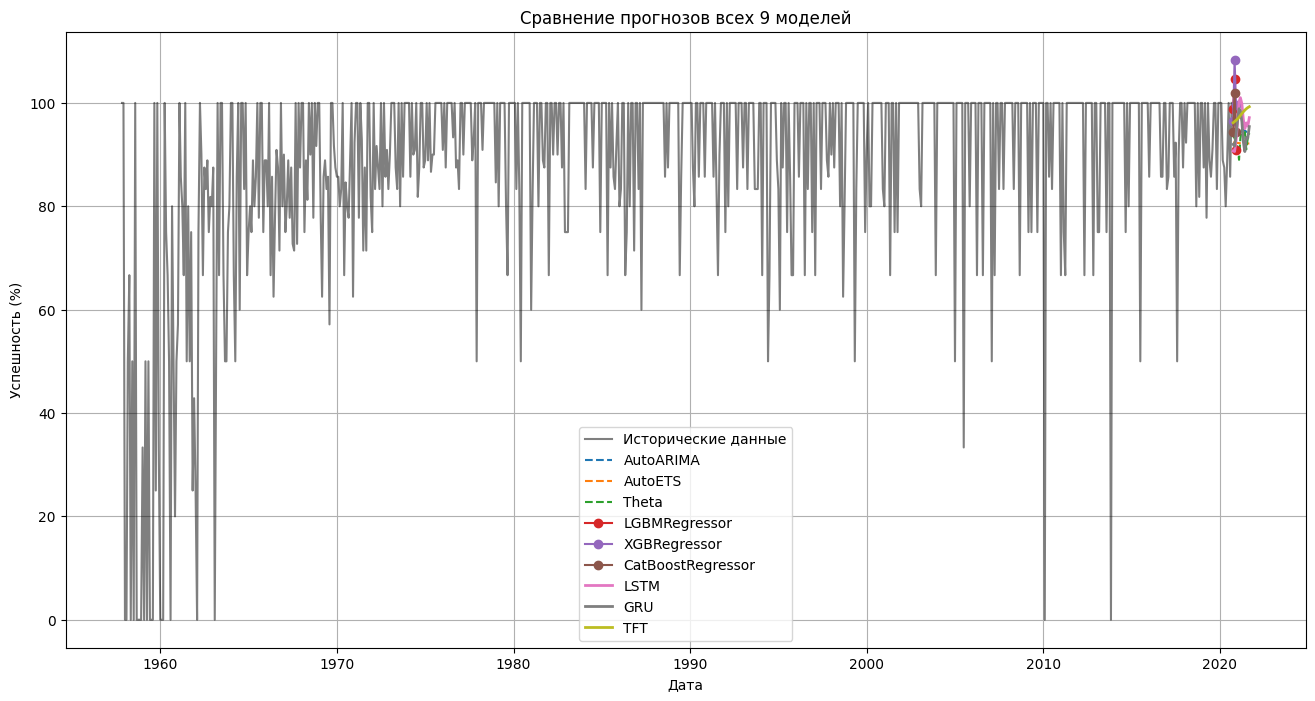

In [ ]:
# Полный пайплайн анализа временных рядов (запускать одной ячейкой)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Theta
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, TFT
from neuralforecast.losses.pytorch import MAE

# 1. Загрузка и очистка данных
df = pd.read_csv('Space_Corrected.csv')
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')
df = df.set_index('Datum')
df['IsSuccess'] = (df['Status Mission'] == 'Success').astype(int)

# 2. Подготовка временного ряда (ежемесячная успешность)
monthly_success = df.resample('M')['IsSuccess'].mean() * 100
monthly_success = monthly_success.fillna(0)

ts_data = monthly_success.reset_index()
ts_data.columns = ['ds', 'y']
ts_data['unique_id'] = 'success_rate'

# 3. Статистические модели (StatsForecast)
models_stats = [AutoARIMA(season_length=12), AutoETS(season_length=12), Theta(season_length=12)]
sf = StatsForecast(models=models_stats, freq='M')
forecast_stats = sf.forecast(h=12, df=ts_data)

# 4. ML-модели (MLForecast)
mlf = MLForecast(
    models=[LGBMRegressor(random_state=42), XGBRegressor(random_state=42), CatBoostRegressor(random_state=42, verbose=0)],
    freq='M',
    lags=[1, 2, 3, 6, 12],
    target_transforms=[Differences([1])]
)
mlf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')
forecast_ml = mlf.predict(h=12)

# 5. DL-модели (NeuralForecast)
nf = NeuralForecast(
    models=[LSTM(h=12, input_size=12, max_steps=100), GRU(h=12, input_size=12, max_steps=100), TFT(h=12, input_size=12, max_steps=100)],
    freq='M'
)
nf.fit(ts_data, id_col='unique_id', time_col='ds', target_col='y')
forecast_dl = nf.predict()

# 6. Визуализация всех прогнозов
plt.figure(figsize=(16, 8))
plt.plot(ts_data['ds'], ts_data['y'], label='Исторические данные', color='black', alpha=0.5)

# Статистические
for model in ['AutoARIMA', 'AutoETS', 'Theta']:
    plt.plot(forecast_stats['ds'], forecast_stats[model], label=model, linestyle='--')

# ML (только первые 3 точки, чтобы не засорять график)
for model in ['LGBMRegressor', 'XGBRegressor', 'CatBoostRegressor']:
    plt.plot(forecast_ml['ds'][:3], forecast_ml[model][:3], label=model, marker='o')

# DL
for model in ['LSTM', 'GRU', 'TFT']:
    plt.plot(forecast_dl['ds'], forecast_dl[model], label=model, linewidth=2)

plt.title('Сравнение прогнозов всех 9 моделей')
plt.xlabel('Дата')
plt.ylabel('Успешность (%)')
plt.legend()
plt.grid(True)
plt.show()